**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 须遵守与协作相同的政策。与其他协作者一样，每位学生都必须独立于交互输出撰写解答，并在提交内容中注明协作的性质。使用生成式 AI 工具完成作业中的实质性部分不符合本作业的精神，并将违反[荣誉准则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。\n

**学生声明（必须填写）**

**SUNet ID：**  
_你的 SUNet ID_

**你是否使用了生成式 AI 工具（例如 ChatGPT、Copilot 等）？**  
- [ ] 否  
- [ ] 是（请在下方说明）

**如果使用了，请说明你如何使用生成式 AI，以及用于作业的哪些部分：**  
_你的回答_

**请确认提交的所有内容均反映你自己的理解，且你没有依赖 AI 完成作业中的实质性部分：**  
- [ ] 我确认

# 使用 Transformer 生成图像描述
你已经实现了普通 RNN，并将其用于图像描述任务。在本 Notebook 中，你将实现 Transformer 解码器的关键部分，以完成同一任务。

**注意：**与 RNN Notebook 不同，本 Notebook 将主要使用 PyTorch 而不是 NumPy 编写。

In [25]:
# Setup cell.
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import sys
import types
import importlib

from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.transformer_layers import *
from cs231n.captioning_solver_transformer import CaptioningSolverTransformer
from cs231n.classifiers.transformer import CaptioningTransformer
from cs231n.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from cs231n.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # Set default size of plots.
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# COCO 数据集
与之前的 Notebook 一样，我们将使用 COCO 数据集进行图像描述。

In [3]:
# Load COCO data from disk into a dictionary.
data = load_coco_data(pca_features=True)

# Print out all the keys and values from the data dictionary.
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment3\cs231n\datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


# Transformer
如你所见，RNN 非常强大，但训练速度往往较慢。此外，RNN 很难编码长距离依赖关系（LSTM 是缓解这一问题的一种方法）。2017 年，Vaswani 等人在论文 [“Attention Is All You Need”](https://arxiv.org/abs/1706.03762) 中提出 Transformer，目标是：（a）引入并行计算；（b）使模型能够学习长距离依赖关系。这篇论文不仅催生了自然语言处理领域的 BERT、GPT 等知名模型，也在包括视觉在内的各个领域引发了研究热潮。虽然这里是在图像描述任务的背景下介绍该模型，但注意力本身是一种更加通用的思想。

# Transformer：多头注意力

### 点积注意力

回顾一下，注意力可以视为对查询 $q\in\mathbb{R}^d$、一组值向量 $\{v_1,\dots,v_n\}, v_i\in\mathbb{R}^d$ 和一组键向量 $\{k_1,\dots,k_n\}, k_i \in\mathbb{R}^d$ 执行的操作，定义如下：

$$
\begin{aligned}
c &= \sum_{i=1}^{n} v_i \alpha_i \\
\alpha_i &= \frac{\exp(k_i^\top q)}{\sum_{j=1}^{n} \exp(k_j^\top q)} \\
\end{aligned}
$$

其中，$\alpha_i$ 通常称为“注意力权重”，输出 $c\in\mathbb{R}^d$ 是值向量按相应权重计算的加权平均。

### 自注意力
在 Transformer 中，我们执行自注意力，这意味着值、键和查询都来自输入 $X \in \mathbb{R}^{\ell \times d}$，其中 $\ell$ 是序列长度。具体来说，我们学习参数矩阵 $V,K,Q \in \mathbb{R}^{d\times d}$，按如下方式映射输入 $X$：

$$
\begin{aligned}
v_i = Vx_i\ \ i \in \{1,\dots,\ell\}\\
k_i = Kx_i\ \ i \in \{1,\dots,\ell\}\\
q_i = Qx_i\ \ i \in \{1,\dots,\ell\}
\end{aligned}
$$

### 多头缩放点积注意力
在多头注意力中，我们为每个头学习一个参数矩阵，使模型能够更灵活地关注输入的不同部分。令 $h$ 为头的数量，$Y_i$ 为第 $i$ 个头的注意力输出。于是，我们分别学习矩阵 $Q_i$、$K_i$ 和 $V_i$。为了使总体计算量与单头情况保持一致，选择 $Q_i \in \mathbb{R}^{d\times d/h}$、$K_i \in \mathbb{R}^{d\times d/h}$ 和 $V_i \in \mathbb{R}^{d\times d/h}$。在上述简单点积注意力中加入缩放因子 $\frac{1}{\sqrt{d/h}}$，得到：

$$
Y_i = \text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)(XV_i)
$$

其中 $Y_i\in\mathbb{R}^{\ell \times d/h}$，$\ell$ 是序列长度。

在实现中，我们对注意力权重应用 dropout（尽管实践中也可以在任意步骤使用 dropout）：

$$
Y_i = \text{dropout}\bigg(\text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)\bigg)(XV_i)
$$

最后，自注意力的输出是所有头拼接结果的线性变换：

$$
Y = [Y_1;\dots;Y_h]A
$$

其中 $A \in\mathbb{R}^{d\times d}$，且 $[Y_1;\dots;Y_h]\in\mathbb{R}^{\ell \times d}$。

请在 `cs231n/transformer_layers.py` 文件的 `MultiHeadAttention` 类中实现多头缩放点积注意力。下面的代码将检查你的实现；相对误差应小于 `7e-3`。

In [3]:
torch.manual_seed(231)

# Choose dimensions such that they are all unique for easier debugging:
# Specifically, the following values correspond to N=1, H=2, T=3, E//H=4, and E=8.
batch_size = 1
sequence_length = 3
embed_dim = 8
attn = MultiHeadAttention(embed_dim, num_heads=2)
attn.eval()

# Self-attention.
data = torch.randn(batch_size, sequence_length, embed_dim)
self_attn_output = attn(query=data, key=data, value=data)

# Masked self-attention.
mask = torch.randn(sequence_length, sequence_length) < 0.5
masked_self_attn_output = attn(query=data, key=data, value=data, attn_mask=mask)

# Attention using two inputs.
other_data = torch.randn(batch_size, sequence_length, embed_dim)
attn_output = attn(query=data, key=other_data, value=other_data)

expected_self_attn_output = np.asarray([[
    [-0.1030,  0.2090,  0.7481, -0.4116, -0.2772,  0.2357, -0.2740, -0.2798],
    [-0.1794,  0.1637,  0.6930, -0.3435, -0.2300,  0.2457, -0.2504, -0.2323],
    [-0.1861,  0.1567,  0.6677, -0.3078, -0.2731,  0.2302, -0.2714, -0.2082]]])

expected_masked_self_attn_output = np.asarray([[
    [-0.1209,  0.1806,  0.8056, -0.4654, -0.2262,  0.2552, -0.2544, -0.2812],
    [-0.2374,  0.1183,  0.7423, -0.3777, -0.1460,  0.2716, -0.2213, -0.2077],
    [-0.0851,  0.2423,  0.7941, -0.3778, -0.4924,  0.1512, -0.4241, -0.1740]]])

expected_attn_output = np.asarray([[
    [-0.1965,  0.0702,  0.5227, -0.1388, -0.3530,  0.2163, -0.2643, -0.1902],
    [-0.3592, -0.0899,  0.5836,  0.0029, -0.3643,  0.2667, -0.1973, -0.1698],
    [-0.3795,  0.0433,  0.5634, -0.0749, -0.4379,  0.2714, -0.2207, -0.1980]]])

print('self_attn_output error: ', rel_error(expected_self_attn_output, self_attn_output.detach().numpy()))
print('masked_self_attn_output error: ', rel_error(expected_masked_self_attn_output, masked_self_attn_output.detach().numpy()))
print('attn_output error: ', rel_error(expected_attn_output, attn_output.detach().numpy()))

self_attn_output error:  0.0001792071437561575
masked_self_attn_output error:  9.809519326315612e-05
attn_output error:  0.006226898176165351


# 位置编码

虽然 Transformer 可以轻松关注输入中的任意部分，但注意力机制本身没有标记顺序的概念。然而，对于许多任务（尤其是自然语言处理），标记的相对顺序非常重要。为了恢复顺序信息，论文作者在每个词元的嵌入中加入位置编码。

定义矩阵 $P \in \mathbb{R}^{l\times d}$，其中 $P_{ij} = $

$$
\begin{cases}
\text{sin}\left(i \cdot 10000^{-\frac{j}{d}}\right) & \text{if j is even} \\
\text{cos}\left(i \cdot 10000^{-\frac{(j-1)}{d}}\right) & \text{otherwise} \\
\end{cases}
$$

我们不再将输入 $X \in \mathbb{R}^{l\times d}$ 直接传入网络，而是传入 $X + P$。

请在 `cs231n/transformer_layers.py` 的 `PositionalEncoding` 中实现这一层。完成后运行下面的简单测试；误差应在 `e-3` 数量级或更小。

In [11]:
torch.manual_seed(231)

batch_size = 1
sequence_length = 2
embed_dim = 6
data = torch.randn(batch_size, sequence_length, embed_dim)

pos_encoder = PositionalEncoding(embed_dim)
pos_encoder.eval()
output = pos_encoder(data)

expected_pe_output = np.asarray([[[-1.1106,  1.0014,  1.5280, -0.0778, -0.6964,  1.1455],
                                  [ 0.8125, -0.4303,  0.4981,  0.7320,  1.1380,  1.5331]]])
print('pe_output error: ', rel_error(expected_pe_output, output.detach().numpy()))

pe_output error:  0.00021699471301977143


# 随堂问题 1

在设计上面介绍的缩放点积注意力时，采用了若干关键设计决策。请解释为什么以下选择是有益的：
1. 使用多个注意力头，而不是单个注意力头。
2. 应用 softmax 函数之前除以 $\sqrt{d/h}$。回顾一下，$d$ 是特征维度，$h$ 是头的数量。
3. 对注意力操作的输出添加线性变换。

每个选择只需回答一两句话，但请务必具体说明：如果不采用对应的实现细节会发生什么、为什么这种情况并不理想，以及所提出的实现如何改善这种情况。

**你的回答：**

# Transformer 解码器块

Transformer 解码器层由三个模块组成：（1）处理输入向量序列的自注意力模块；（2）根据可用上下文（在本例中为图像特征）进行处理的交叉注意力模块；（3）独立处理序列中每个向量的前馈模块。补全 `cs231n/transformer_layers.py` 中的 `TransformerDecoderLayer` 实现，并在下方测试；相对误差应小于 1e-6。

Transformer 解码器层有三个主要组件：（1）处理输入向量序列的自注意力模块；（2）融合额外上下文（例如本例中的图像特征）的交叉注意力模块；（3）独立处理序列中每个向量的前馈模块。补全 `cs231n/transformer_layers.py` 中的 `TransformerDecoderLayer` 实现，并在下方测试；相对误差应小于 1e-6。

In [4]:
torch.manual_seed(231)
np.random.seed(231)

N, T, TM, D = 1, 4, 5, 12

decoder_layer = TransformerDecoderLayer(D, 2, 4*D)
decoder_layer.eval()
tgt = torch.randn(N, T, D)
memory = torch.randn(N, TM, D)
tgt_mask = torch.randn(T, T) < 0.5

output = decoder_layer(tgt, memory, tgt_mask)

expected_output = np.asarray([
    [[ 0.27005595, -0.21056601,  0.63376445, -0.35391954,  0.60071295,
      -1.7566615,  -0.1314159,  -1.7659538,  -0.5575517,   0.680143,
       1.8622686,   0.7291234],
     [-0.6080135,   0.4421802,  -0.07590749, -0.12093157,  0.94722354,
      -1.0223433,   0.47332686, -1.3958666,   2.1890075,  -1.0380646,
       0.9437816,  -0.7343922],
     [-0.89690155,  0.60447216,  0.10688882,  0.03492759,  1.8388084,
      -0.9772293,   0.7621334,  -0.668234,    1.3260399,  -1.8417019,
       0.21718435, -0.506388],
     [-0.70961505, -0.02918372, -0.39894593, -0.8069395,   0.04967685,
       0.29345992,  0.7871747,  -1.3172938,   1.4744806,   1.2633642,
       1.1611108,  -1.767289]]
])
print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  1.5224654802442538e-06


# 用于图像描述的 Transformer
实现前面的各层后，就可以将它们组合起来，构建基于 Transformer 的图像描述模型。打开 `cs231n/classifiers/transformer.py`，查看 `CaptioningTransformer` 类。

实现该类的 `forward` 函数。完成后，运行下面的小型测试用例检查前向传播；误差应在 `e-5` 数量级或更小。

In [8]:
torch.manual_seed(231)
np.random.seed(231)

N, D, W = 4, 20, 30
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(word_to_idx)
T = 3

transformer = CaptioningTransformer(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    num_heads=2,
    num_layers=2,
    max_length=30
)
transformer.eval()

features = torch.randn(N, D)
captions = torch.randint(0, V, (N, T))

scores = transformer(features, captions)

expected_scores = np.asarray([
    [[ 0.62165695, -0.6203744,  -1.116114  ],
     [ 0.6641097,  -0.60309553, -1.3479083 ],
     [ 0.62117404, -0.79205745, -1.1095243 ]],
    [[ 0.62160987, -0.6214724,  -1.1171186 ],
     [ 0.6093992,  -0.61166143, -1.3365762 ],
     [ 0.62108713, -0.79322916, -1.1104958 ]],
    [[ 0.6406587,  -0.57419956, -1.1300566 ],
     [ 0.6075228,  -0.60872054, -1.3372457 ],
     [ 0.6471472,  -0.8270494,  -1.1064028 ]],
    [[ 0.64029807, -0.5755552,  -1.1284486 ],
     [ 0.60708034, -0.6099963,  -1.3356377 ],
     [ 0.59367496, -0.8346836,  -1.0914496 ]]
])

print('scores error: ', rel_error(expected_scores, scores.detach().numpy()))

scores error:  2.3625152955512965e-07


# 在小规模数据上过拟合 Transformer 图像描述模型
运行下面的代码，让基于 Transformer 的图像描述模型在之前用于 RNN 的同一小型数据集上过拟合。

In [32]:
torch.manual_seed(231)
np.random.seed(231)

data = load_coco_data(max_train=50)

transformer = CaptioningTransformer(
          word_to_idx=data['word_to_idx'],
          input_dim=data['train_features'].shape[1],
          wordvec_dim=256,
          num_heads=2,
          num_layers=2,
          max_length=30
        )


transformer_solver = CaptioningSolverTransformer(transformer, data, idx_to_word=data['idx_to_word'],
           num_epochs=100,
           batch_size=25,
           learning_rate=0.001,
           verbose=True, print_every=10,
         )

transformer_solver.train()

# Plot the training losses.
plt.plot(transformer_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

base dir  C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment3\cs231n\datasets/coco_captioning
(Iteration 1 / 200) loss: 5.042450
(Iteration 11 / 200) loss: 2.766581
(Iteration 21 / 200) loss: 1.981896
(Iteration 31 / 200) loss: 1.590641
(Iteration 41 / 200) loss: 1.230506


KeyboardInterrupt: 

打印最终训练损失。最终损失应小于 0.05。

In [10]:
print('Final loss: ', transformer_solver.loss_history[-1])

Final loss:  0.014563442


# 测试时的 Transformer 采样
采样代码已为你写好。直接运行下面的代码，与之前的 RNN 结果进行比较。由于训练数据很少，与之前一样，训练集上的结果应明显优于验证集。

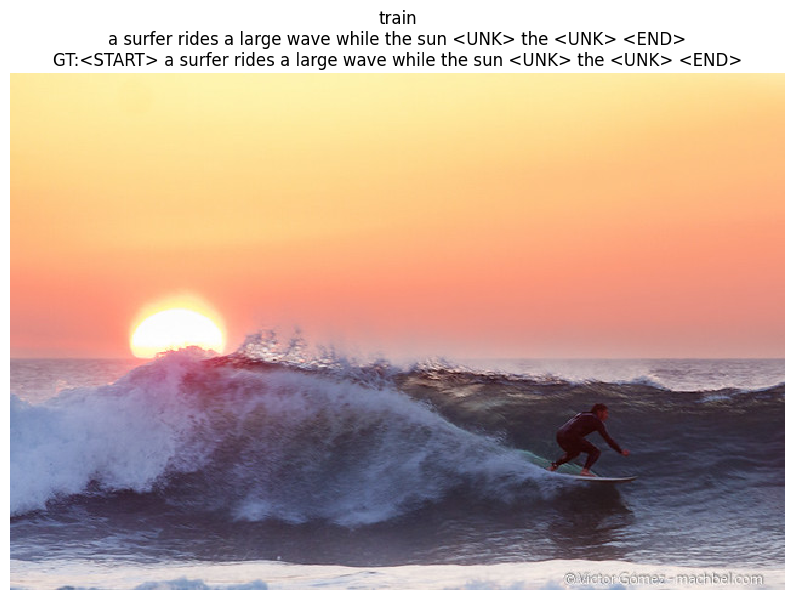

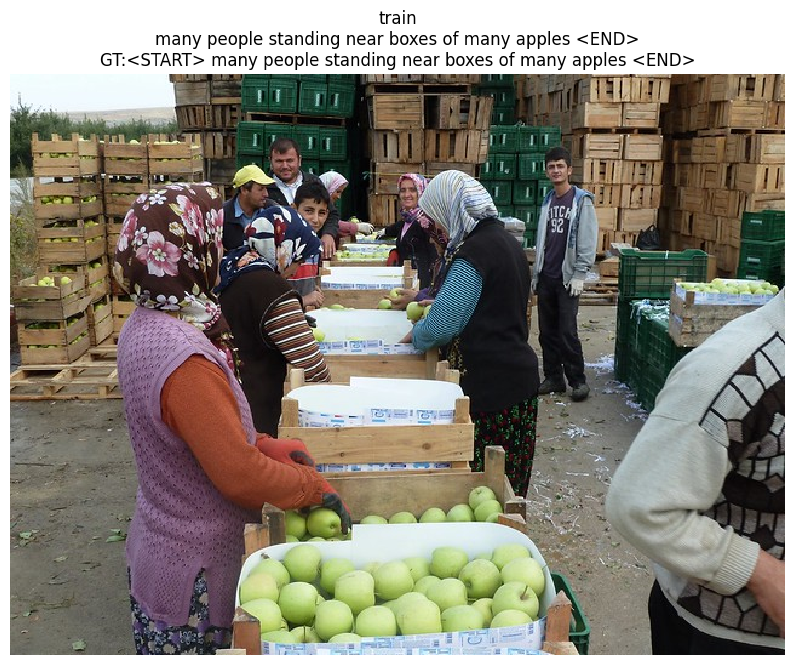

URL Error:  Not Found http://farm1.staticflickr.com/83/241537113_6c6171a1ec_z.jpg
URL Error:  Not Found http://farm7.staticflickr.com/6038/6364580705_12de27ab54_z.jpg


In [12]:
# If you get an error, the URL just no longer exists, so don't worry!
# You can re-sample as many times as you want.
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = transformer.sample(features, max_length=30)
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # Skip missing URLs.
        if img is None: continue
        plt.imshow(img)
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# 视觉 Transformer（ViT）

[Dosovitskiy 等人](https://arxiv.org/abs/2010.11929)证明，将 Transformer 模型应用于图像块序列（称为视觉 Transformer），不仅可以取得出色性能，而且在大型数据集上训练时，其扩展性也优于卷积神经网络。我们将利用现有的 Transformer 组件实现一个视觉 Transformer，并在 CIFAR-10 数据集上训练。

视觉 Transformer 将输入图像转换为固定大小的图块序列，并将每个图块嵌入为潜在向量。请补全 `cs231n/transformer_layers.py` 中的 `PatchEmbedding` 实现，并在下方测试；相对误差应小于 1e-4。

In [15]:
from cs231n.transformer_layers import PatchEmbedding

torch.manual_seed(231)
np.random.seed(231)

N = 2
HW = 16
PS = 8
D = 8

patch_embedding = PatchEmbedding(
    img_size=HW,
    patch_size=PS,
    embed_dim=D
)

x = torch.randn(N, 3, HW, HW)
output = patch_embedding(x)

expected_output = np.asarray([
        [[-0.6312704 ,  0.02531429,  0.6112642 , -0.49089882,
          0.01412961, -0.6959372 , -0.32862484, -0.45402682],
        [ 0.18816411, -0.08142513, -0.9829535 , -0.23975623,
         -0.23109074,  0.97950286, -0.40997326,  0.7457837 ],
        [ 0.01810865,  0.15780598, -0.91804236,  0.36185235,
          0.8379501 ,  1.0191797 , -0.29667392,  0.20322265],
        [-0.18697818, -0.45137224, -0.40339014, -1.4381214 ,
         -0.43450755,  0.7651071 , -0.83683825, -0.16360264]],

       [[-0.39786366,  0.16201034, -0.19008337, -1.0602452 ,
         -0.28693503,  0.09791763,  0.26614824,  0.41781986],
        [ 0.35146567, -0.4469593 , -0.1841726 ,  0.45757473,
         -0.61304873, -0.29104248, -0.16124889, -0.14987172],
        [-0.2996967 ,  0.27353522, -0.09929767,  0.01973832,
         -1.2312065 , -0.6374332 , -0.22963578,  0.55696607],
        [-0.93818814,  0.02465284, -0.21117875,  1.1860403 ,
         -0.06137538, -0.21062079, -0.094347  ,  0.50032747]]])

print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  5.93853582728669e-06


图块向量序列由 Transformer 编码器层处理，每层都包含自注意力模块和前馈模块。由于所有向量都会相互关注，严格来说并不需要注意力掩码。不过，为保持一致，我们仍然会实现它。

请实现 `cs231n/transformer_layers.py` 中的 `TransformerEncoderLayer`，并在下方测试；相对误差应小于 1e-6。

In [17]:
torch.manual_seed(231)
np.random.seed(231)

from cs231n.transformer_layers import TransformerEncoderLayer

N, T, TM, D = 1, 4, 5, 12

encoder_layer = TransformerEncoderLayer(D, 2, 4*D)
encoder_layer.eval()
x = torch.randn(N, T, D)
x_mask = torch.randn(T, T) < 0.5

output = encoder_layer(x, x_mask)

expected_output = np.asarray([
    [[-0.48887438, -0.16470742,  0.7249629,  -1.0907345,   1.5764195,
       0.17484017,  0.8643941,  -0.5209561,  -1.6651545,  -1.1943513,
       1.4809005,   0.30326116],
     [-0.14663944,  1.052812,   -0.96227,    -0.20350897, -2.1478589,
       1.2637341,   0.04015125, -0.945255,    1.408903,   -0.43051198,
       0.37110543,  0.69933903],
     [ 0.08718029,  0.91050833, -1.208469,    1.1440394,  -1.9794976,
      -0.38342738, -0.47407156, -0.17345548,  0.11738186,  1.9534125,
       0.3525986,  -0.3461999],
     [-0.81389004,  0.76213264, -0.7094313,  -1.5332246,   1.3837544,
       0.4091982,   0.6569406,   0.7305365,  -1.197077,   -1.3698943,
       0.58292854,  1.0980265]]
])

print('error: ', rel_error(expected_output, output.detach().numpy()))

error:  9.230481707432173e-07


请查看 `cs231n/classifiers/transformer.py` 中 `VisionTransformer` 的实现。

为了进行分类，ViT 将输入图像划分为图块，并使用 Transformer 处理图块向量序列。最后，对所有图块向量进行平均池化，并用其预测图像类别。我们将继续使用相同的一维正弦位置编码来注入顺序信息，不过二维正弦位置编码和可学习位置编码也是有效选择。

补全 ViT 的前向传播并在下方测试；相对误差应小于 1e-6。

In [19]:
torch.manual_seed(231)
np.random.seed(231)
from cs231n.classifiers.transformer import VisionTransformer

imgs = torch.randn(3, 3, 32, 32)
transformer = VisionTransformer()
transformer.eval()

scores = transformer(imgs)

expected_scores = np.asarray(
    [[-0.15802915,  0.15734261, -0.06002094, -0.1860142,  -0.09376919,
      -0.08837911,  0.16224845,  0.0168601,   0.20606893,  0.13079852],
     [-0.12838936,  0.20798579, -0.0620573,  -0.11705838, -0.14088857,
      -0.11387511,  0.18839046,  0.03078492,  0.17386372,  0.06414902],
     [-0.09435399,  0.20495278, -0.03362986, -0.12232997, -0.15535004,
      -0.10380758,  0.21114832,  0.03481449,  0.18798208,  0.12231653]])

print('scores error: ', rel_error(expected_scores, scores.detach().numpy()))

scores error:  5.11694971127655e-07


首先，通过让模型在一个训练批次上过拟合来验证实现。请相应调节学习率和权重衰减。

In [24]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

cifar10_root = r'C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\datasets'

train_data = CIFAR10(root=cifar10_root, train=True, transform=transforms.ToTensor(), download=False)
test_data = CIFAR10(root=cifar10_root, train=False, transform=transforms.ToTensor(), download=False)

In [38]:

learning_rate = 1e-3  # Experiment with this
weight_decay = 1.e-4  # Experiment with this


batch = next(iter(DataLoader(train_data, batch_size=64, shuffle=False)))
model = VisionTransformer(dropout=0.0)
loss_criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
model.train()

epochs = 100
for epoch in range(epochs):
    imgs, target = batch
    out = model(imgs)
    loss = loss_criterion(out, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    top1 = (out.argmax(-1) == target).float().mean().item()
    if epoch % 10 == 0:
      print(f"[{epoch}/{epochs}] Loss {loss.item():.6f}, Top-1 Accuracy: {top1:.3f}")


[0/100] Loss 2.310390, Top-1 Accuracy: 0.125
[10/100] Loss 2.097692, Top-1 Accuracy: 0.172
[20/100] Loss 1.940311, Top-1 Accuracy: 0.219
[30/100] Loss 1.685555, Top-1 Accuracy: 0.312
[40/100] Loss 1.300027, Top-1 Accuracy: 0.500
[50/100] Loss 1.052844, Top-1 Accuracy: 0.688
[60/100] Loss 0.768875, Top-1 Accuracy: 0.844
[70/100] Loss 0.453791, Top-1 Accuracy: 0.922
[80/100] Loss 0.210932, Top-1 Accuracy: 0.984
[90/100] Loss 0.073509, Top-1 Accuracy: 1.000


In [39]:
# You should get perfect 1.00 accuracy
print(f"Overfitting ViT on one batch. Top-1 accuracy: {top1}")

Overfitting ViT on one batch. Top-1 accuracy: 1.0


现在，我们将在整个数据集上训练模型。

In [40]:
from cs231n.classification_solver_vit import ClassificationSolverViT

############################################################################
# TODO: Train a Vision Transformer model that achieves over 0.45 test      #
# accuracy on CIFAR-10 after 2 epochs by adjusting the model architecture  #
# and/or training parameters as needed.                                    #
#                                                                          #
# Note: If you want to use a GPU runtime, go to `Runtime > Change runtime  #
# type` and set `Hardware accelerator` to `GPU`. This will reset Colab,    #
# so make sure to rerun the entire notebook from the beginning afterward.  #
############################################################################


learning_rate = 1e-3
weight_decay = 0.0
batch_size = 64
model = VisionTransformer(
    img_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=128,
    num_layers=4,
    num_heads=4,
    dim_feedforward=256,
    num_classes=10,
    dropout=0.1,
)




################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

solver = ClassificationSolverViT(
    train_data=train_data,
    test_data=test_data,
    model=model,
    num_epochs = 2,  # Don't change this
    learning_rate = learning_rate,
    weight_decay = weight_decay,
    batch_size = batch_size,
)

solver.train('cuda' if torch.cuda.is_available() else 'cpu')



  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

In [41]:
print(f"Accuracy on test set: {solver.results['best_test_acc']}")

Accuracy on test set: 0.4799


# 随堂问题 2

尽管 ViT 近来在大规模图像识别任务中取得了成功，但在较小数据集上训练时，其表现通常落后于传统 CNN。造成这种性能差距的根本因素是什么？可以采用哪些技术改善 ViT 在小型数据集上的性能？

**你的回答**：请在此填写。

# 随堂问题 3

如果分别进行以下修改，ViT 中自注意力层的计算成本会怎样变化？请忽略 QKV 和输出投影的计算成本。

(i) 将隐藏维度加倍。  
(ii) 将输入图像的高度和宽度都加倍。  
(iii) 将图块大小加倍。  
(iv) 将层数加倍。

**你的回答**：请在此填写。